# LSTM for Crypto Perpetual Funding

The LSTM tests whether a 60-bar sequence of the same 44-feature modeling frame
adds predictive information beyond the flat linear, tree, and TabM models. The
19-symbol panel and two validation folds make checkpoint coverage and lineage
especially important: a cached reader run must reconstruct the registered
result without silently training a second model.

**Learning Objectives**:
- Build causal 60-bar sequences from 39 financial and five fold-temporal features
- Evaluate LSTM checkpoints with decision-time rank IC on purged validation folds
- Reconstruct the current registered checkpoint surface without rewriting the registry
- Compare the registered LSTM with current-lineage linear and GBM baselines

**Book Reference**: Chapter 13, Sections 13.2-13.3

**Prerequisites**: [`04_model_based_features`](04_model_based_features.ipynb),
[`06_linear`](06_linear.ipynb), and [`07_gbm`](07_gbm.ipynb)

In [1]:
"""LSTM sequence model for crypto perpetual funding."""

import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import yaml
from ml4t.diagnostic.metrics import cross_sectional_ic

import utils.style as style
from case_studies.utils.analytics import load_best_ic_per_family
from case_studies.utils.deep_learning import run_dl_cv
from case_studies.utils.registry import (
    build_training_spec,
    compute_fold_metrics_from_predictions,
    load_prediction_metrics,
    load_prediction_sets,
    modeling_input_fingerprint,
    read_predictions,
    training_hash_from_spec,
    training_run_status,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "crypto_perps_funding"
MODEL = "lstm"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
FORCE_RETRAIN = False
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
LOOKBACK = 60
BATCH_SIZE = 2048
MAX_FOLDS = 0
TRAIN_DEVICE = "cuda"
SEED = 42

In [3]:
set_global_seeds(SEED)
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
PRIMARY_LABEL = PRIMARY_LABEL or setup["labels"]["primary"]

if TRAIN_DEVICE not in {"cpu", "cuda"}:
    raise ValueError("TRAIN_DEVICE must be 'cpu' or 'cuda'")
if TRAIN_DEVICE != "cuda":
    raise ValueError("Crypto publication LSTM training requires TRAIN_DEVICE='cuda'")
if not torch.cuda.is_available():
    raise RuntimeError("Crypto LSTM requires CUDA, but PyTorch cannot see a CUDA device")

print(f"Case study: {CASE_STUDY_ID} | Model: {MODEL}")
print(f"Device: {TRAIN_DEVICE} | Epochs: {N_EPOCHS} | Lookback: {LOOKBACK}")

Case study: crypto_perps_funding | Model: lstm
Device: cuda | Epochs: 100 | Lookback: 60


## 1. Canonical Modeling Frame

The loader assembles the signed 39-feature financial emit with five temporal
features fitted separately for each fold. The 2024-2025 holdout remains sealed.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits[:MAX_FOLDS] if MAX_FOLDS else mds.splits
dataset_pd = dataset.to_pandas()
INPUT_FINGERPRINT = modeling_input_fingerprint(
    CASE_DIR,
    PRIMARY_LABEL,
    splits,
    feature_names,
    MAX_SYMBOLS,
)
IDENTITY_PARAMS = {
    "device": TRAIN_DEVICE,
    "input_fingerprint": INPUT_FINGERPRINT,
    "max_symbols": MAX_SYMBOLS,
    "max_folds": MAX_FOLDS,
    "batch_size": BATCH_SIZE,
    "lookback": LOOKBACK,
}

financial_features = [name for name in feature_names if name not in mds.temporal_feature_names]
assert len(financial_features) == 39
assert len(mds.temporal_feature_names) == 5
assert len(feature_names) == 44
assert label_col not in feature_names
assert dataset.select(date_col, entity_col).is_duplicated().sum() == 0

print(f"Dataset: {len(dataset):,} rows x {len(feature_names)} features")
print(
    f"Feature assembly: {len(financial_features)} financial + {len(mds.temporal_feature_names)} temporal"
)
print(f"Entities: {dataset[entity_col].n_unique()} | Validation folds: {len(splits)}")
print(f"Input lineage: {INPUT_FINGERPRINT[:12]}")

Dataset: 100,741 rows x 44 features
Feature assembly: 39 financial + 5 temporal
Entities: 19 | Validation folds: 2
Input lineage: 962cfd4e882e


## 2. Same-Lineage Baselines

These values come from the same isolated current-lineage registry populated by
notebooks 06 and 07.

In [5]:
prior_baselines = {}
baseline_rows = load_best_ic_per_family(
    ["linear", "gbm", "tabular_dl"], case_studies=[CASE_STUDY_ID]
)
for row in baseline_rows.iter_rows(named=True):
    if row["family"] == "linear":
        prior_baselines["Linear"] = float(row["ic_mean"])
    elif row["family"] == "gbm":
        prior_baselines["GBM"] = float(row["ic_mean"])
    elif row["family"] == "tabular_dl":
        prior_baselines["TabM"] = float(row["ic_mean"])

for name, ic_value in prior_baselines.items():
    print(f"  {name}: current validation IC={ic_value:+.4f}")

  GBM: current validation IC=+0.0288
  Linear: current validation IC=+0.0070
  TabM: current validation IC=+0.0151


## 3. Current Reconstruction or Fresh Training

A complete current-lineage registry exposes every physical prediction set. The
notebook reads and re-scores that surface without calling the trainer. A missing
current identity runs the CUDA path and evaluates every physical checkpoint.

In [6]:
dl_configs = [
    config
    for config in load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "deep_learning")
    if config["params"].get("architecture") == MODEL
]
for config in dl_configs:
    config["n_epochs"] = N_EPOCHS
    config["batch_size"] = BATCH_SIZE
    config["params"]["lookback"] = LOOKBACK

print(f"Grid: {len(dl_configs)} config x {len(splits)} folds x {N_EPOCHS} epochs")

Grid: 1 config x 2 folds x 100 epochs


Physical predictions are the metric oracle. IC is computed within each decision
timestamp and then averaged, preserving equal weight across decisions.

In [7]:
def _checkpoint_metrics(config_name: str, epoch: int, frame: pl.DataFrame) -> dict:
    """Score one physical checkpoint on decision-time rank IC."""
    stats = cross_sectional_ic(
        frame,
        frame,
        pred_col="y_score",
        ret_col="y_true",
        date_col=date_col,
        entity_col=entity_col,
        min_obs=5,
    )
    return {
        "config": config_name,
        "epoch": int(epoch),
        "ic_mean": float(stats["ic_mean"]),
        "ic_std": float(stats["ic_std"]),
        "ic_n_days": int(stats["n_periods"]),
        "n_obs": frame.height,
        "n_null": int(frame["y_score"].null_count() + frame["y_score"].is_nan().sum()),
    }

Fresh selection admits only unique, finite, null-free checkpoints with maximum
validation-date coverage.

In [8]:
def _canonical_result(all_predictions: pl.DataFrame, *, lineage: str) -> dict:
    """Select the complete checkpoint with the highest pooled IC."""
    keys = [date_col, entity_col, "fold_id", "config", "epoch"]
    if all_predictions.select(keys).is_duplicated().any():
        raise ValueError("Duplicate sequence checkpoint prediction keys")
    curves = pl.DataFrame(
        [
            _checkpoint_metrics(config_name, epoch, frame)
            for (config_name, epoch), frame in all_predictions.partition_by(
                ["config", "epoch"], as_dict=True, maintain_order=True
            ).items()
        ]
    )
    full_days = int(curves["ic_n_days"].max())
    curves = curves.with_columns(
        (
            (pl.col("ic_n_days") == full_days)
            & (pl.col("n_null") == 0)
            & pl.col("ic_mean").is_finite()
        ).alias("selectable")
    )
    winner = curves.filter("selectable").sort("ic_mean", descending=True).row(0, named=True)
    selected = all_predictions.filter(
        (pl.col("config") == winner["config"]) & (pl.col("epoch") == winner["epoch"])
    )
    return {
        "lineage": lineage,
        "best_config_name": winner["config"],
        "best_epoch": winner["epoch"],
        "best_ic": winner["ic_mean"],
        "predictions": selected,
        "all_predictions": all_predictions,
        "all_learning_curves": curves,
        "fold_metrics": compute_fold_metrics_from_predictions(
            all_predictions, winner["config"], winner["epoch"], date_col=date_col
        ),
        "prediction_hash": None,
        "uncertainty": None,
    }

Cached reconstruction requires the exact current training identity and the full
configured checkpoint surface.

In [9]:
def _current_spec(config: dict) -> dict:
    """Build the content-addressed training identity for one LSTM config."""
    return build_training_spec(
        config["family"],
        config["config_name"],
        label_col,
        n_folds=len(splits),
        n_epochs=config.get("n_epochs"),
        extra_params=IDENTITY_PARAMS,
    )

Registry uncertainty belongs to the selected physical prediction set and is
loaded separately from the checkpoint curve.

In [10]:
def _registered_uncertainty(prediction_hash: str) -> dict | None:
    """Load overlap-aware uncertainty for one physical prediction set."""
    frame = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=prediction_hash)
    return frame.row(0, named=True) if frame.height else None

Prediction hashes are de-duplicated before the physical epoch slices are read.

In [11]:
def _cached_result(config: dict) -> dict | None:
    """Reconstruct and independently score the current checkpoint surface."""
    spec = _current_spec(config)
    status = training_run_status(CASE_STUDY_ID, spec)
    training_hash = training_hash_from_spec(spec)
    prediction_sets = load_prediction_sets(
        CASE_STUDY_ID, training_hash=training_hash, split=PREDICTION_SPLIT
    )
    if FORCE_RETRAIN or not status.complete or prediction_sets.is_empty():
        return None
    expected_epochs = sorted(
        {
            *range(
                config["checkpoint_interval"],
                config["n_epochs"] + 1,
                config["checkpoint_interval"],
            ),
            config["n_epochs"],
        }
    )
    actual_epochs = sorted(int(value) for value in prediction_sets["checkpoint_value"])
    if actual_epochs != expected_epochs:
        raise ValueError(f"Incomplete LSTM checkpoint surface: {actual_epochs}")

    frames = []
    seen_hashes = set()
    for prediction_set in prediction_sets.iter_rows(named=True):
        prediction_hash = prediction_set["prediction_hash"]
        if prediction_hash in seen_hashes:
            continue
        seen_hashes.add(prediction_hash)
        epoch = int(prediction_set["checkpoint_value"])
        frame = read_predictions(CASE_STUDY_ID, prediction_hash)
        frames.append(
            frame.with_columns(
                pl.lit(config["config_name"]).alias("config"),
                pl.lit(epoch).alias("epoch"),
            )
        )
    result = _canonical_result(
        pl.concat(frames, how="diagonal_relaxed"),
        lineage="current registered CUDA predictions",
    )
    selected_set = prediction_sets.filter(pl.col("checkpoint_value") == result["best_epoch"]).row(
        0, named=True
    )
    result["prediction_hash"] = selected_set["prediction_hash"]
    result["uncertainty"] = _registered_uncertainty(selected_set["prediction_hash"])
    return result

A missing current identity takes the full CUDA training path.

In [12]:
def _train_fresh_result() -> dict:
    """Train missing LSTM checkpoints and apply canonical fresh selection."""
    raw_result = run_dl_cv(
        dataset_pd,
        splits,
        feature_names=feature_names,
        label_col=label_col,
        date_col=date_col,
        entity_col=entity_col,
        configs=dl_configs,
        n_features=len(feature_names),
        device=TRAIN_DEVICE,
        save_dir=CASE_DIR / "run_log" / "training" / "deep_learning",
        register=True,
        force_retrain=FORCE_RETRAIN,
        prediction_split=PREDICTION_SPLIT,
        case_study=CASE_STUDY_ID,
        notebook="09_dl_lstm",
        temporal_by_fold=mds.temporal_by_fold,
        temporal_keys=mds.temporal_keys,
        temporal_feature_names=mds.temporal_feature_names,
        identity_params=IDENTITY_PARAMS,
    )
    result = _canonical_result(
        raw_result["all_predictions"],
        lineage="fresh current CUDA training",
    )
    result["prediction_hash"] = None
    result["uncertainty"] = None
    return result

Resolve the physical result before any chart or conclusion is assembled.

In [13]:
result = _cached_result(dl_configs[0])
if result is None:
    result = _train_fresh_result()

best_name = result["best_config_name"]
best_epoch = result["best_epoch"]
best_ic = result["best_ic"]
predictions = result["predictions"]
curves = result["all_learning_curves"]

print(f"Lineage: {result['lineage']}")
print(f"Selected: {best_name} at epoch {best_epoch}, IC={best_ic:+.6f}")
print(f"Coverage: {predictions[date_col].n_unique():,} dates, {predictions.height:,} rows")

Lineage: current registered CUDA predictions
Selected: lstm_h64 at epoch 15, IC=+0.017955
Coverage: 2,183 dates, 35,228 rows


## 4. Checkpoint History

Every point is re-scored from a physical prediction set using pooled
decision-time IC. The highlighted point is the current selected checkpoint.

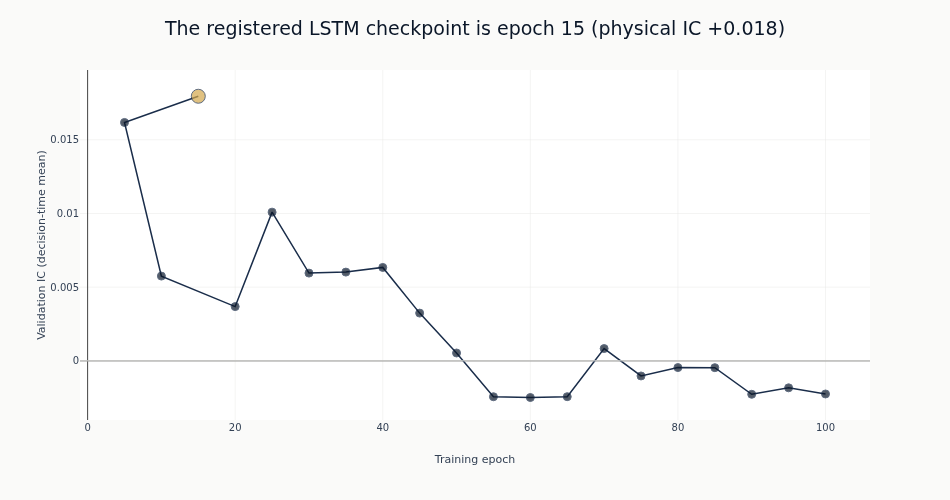

In [14]:
if curves.height:
    selected_mask = (
        curves["selected"].to_list()
        if "selected" in curves.columns
        else (curves["epoch"] == best_epoch).to_list()
    )
    colors = [
        style.COLORS["amber"] if selected else style.COLORS["blue"] for selected in selected_mask
    ]
    curve_figure = go.Figure(
        go.Scatter(
            x=curves["epoch"],
            y=curves["ic_mean"],
            mode="lines+markers",
            line=dict(color=style.COLORS["slate"], width=1.5),
            marker=dict(color=colors, size=[14 if selected else 8 for selected in selected_mask]),
            showlegend=False,
        )
    )
    curve_figure.add_hline(y=0, line=dict(color=style.COLORS["silver_muted"], width=1))
    curve_figure.update_layout(
        title=f"The registered LSTM checkpoint is epoch {best_epoch} (physical IC {best_ic:+.3f})",
        height=500,
        width=950,
        margin=dict(t=70),
    )
    curve_figure.update_xaxes(title_text="Training epoch")
    curve_figure.update_yaxes(title_text="Validation IC (decision-time mean)")
    curve_figure.show()

## 5. Same-Lineage Model Comparison

All values come from the same current input lineage and isolated registry.

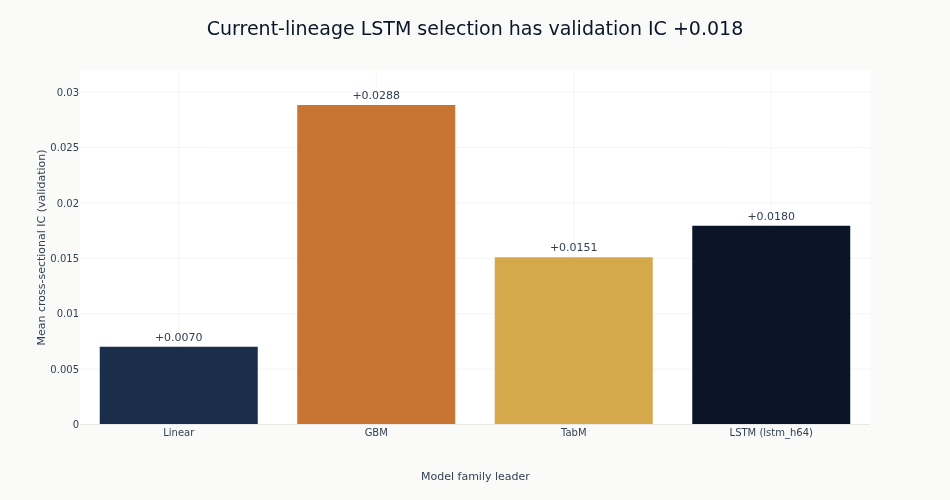

In [15]:
baseline_order = ["Linear", "GBM", "TabM"]
comparison_names = [name for name in baseline_order if name in prior_baselines]
comparison_values = [prior_baselines[name] for name in comparison_names]
comparison_colors = [
    style.COLORS["slate"]
    if name == "Linear"
    else style.COLORS["copper"]
    if name == "GBM"
    else style.COLORS["amber"]
    for name in comparison_names
]
comparison_names.append(f"LSTM ({best_name})")
comparison_values.append(best_ic)
comparison_colors.append(style.COLORS["blue"])
comparison_title = f"Current-lineage LSTM selection has validation IC {best_ic:+.3f}"
comparison_figure = go.Figure(
    go.Bar(
        x=comparison_names,
        y=comparison_values,
        marker_color=comparison_colors,
        text=[f"{value:+.4f}" for value in comparison_values],
        textposition="outside",
        cliponaxis=False,
    )
)
comparison_figure.add_hline(y=0, line=dict(color=style.COLORS["silver_muted"], width=1))
comparison_figure.update_layout(
    title=comparison_title,
    height=500,
    width=950,
    margin=dict(t=70, b=75),
)
comparison_figure.update_xaxes(title_text=None)
comparison_figure.add_annotation(
    text="Model family leader",
    x=0.5,
    y=-0.17,
    xref="paper",
    yref="paper",
    showarrow=False,
)
comparison_figure.update_yaxes(title_text="Mean cross-sectional IC (validation)")
comparison_figure.show()

## 6. Validation Diagnostics

In [16]:
fold_metrics = result["fold_metrics"]
print("Per-fold validation IC:")
for row in fold_metrics.sort("fold_id").iter_rows(named=True):
    print(f"  Fold {row['fold_id']}: IC={row['ic_mean']:+.4f}")

uncertainty = result["uncertainty"]
if uncertainty and uncertainty.get("ic_ci_lo") is not None:
    print(
        f"HAC 95% CI: [{uncertainty['ic_ci_lo']:+.4f}, {uncertainty['ic_ci_hi']:+.4f}] "
        f"| p={uncertainty['ic_p_hac']:.3f}"
    )

Per-fold validation IC:
  Fold 0: IC=+0.0123
  Fold 1: IC=+0.0236
HAC 95% CI: [+0.0057, +0.0303] | p=0.004


## 7. Key Takeaways

- **Sequence memory helps, but GBM remains the leader.** The current CUDA LSTM
  peaks at validation IC +0.018 at epoch 15, ahead of TabM (+0.015) and Linear
  (+0.007) but below GBM (+0.029). Its HAC 95% interval is [+0.006, +0.030].
- **Selection uses physical checkpoint evidence.** All 20 checkpoints are re-scored
  with equal weight per decision timestamp before the best complete surface is chosen.
- **Cached execution is read-only.** It reconstructs the current fingerprint-bound
  checkpoint surface and does not call the trainer or rewrite the registry.
- **The sequence contract is explicit.** Every fold uses 60-bar, per-symbol
  windows over the signed 39 financial features plus five fold-fitted temporal
  features. Fold preprocessing and the current CUDA result are tested
  independently in the sign-off evidence.

**Next**: [`10_dl_tcn`](10_dl_tcn.ipynb) tests whether dilated convolutions add
useful temporal structure before [`12_model_analysis`](12_model_analysis.ipynb)
compares the signed model families.